In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

df = pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


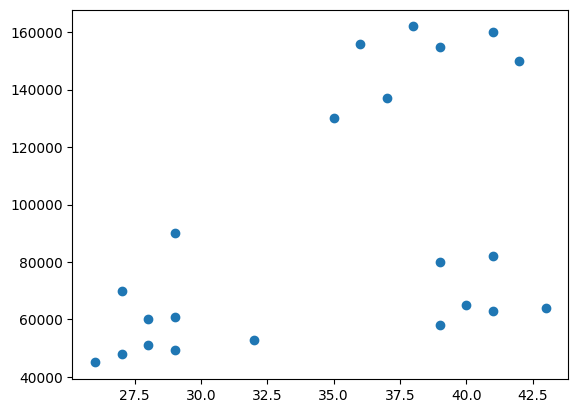

In [7]:
plt.scatter(df["Age"], df["Income($)"])
plt.show()

In [9]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,n_init='auto',random_state=0)
kmeans.fit(df[["Age", "Income($)"]])
kmeans.labels_
kmeans.cluster_centers_

array([[3.29090909e+01, 5.61363636e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.40000000e+01, 8.05000000e+04]])

In [10]:
kmeans.labels_

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [11]:
df["cluster"] = kmeans.labels_
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


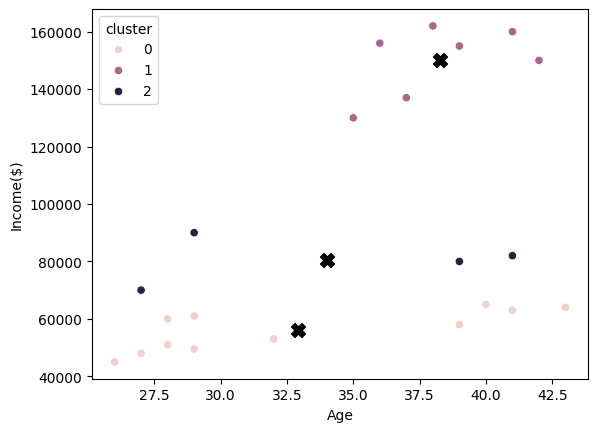

In [12]:
import seaborn as sns
sns.scatterplot(x="Age", y="Income($)", hue="cluster", data=df)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color="black", marker="X", s=100)
plt.show()

In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# empty dataframe 
df_scaled = pd.DataFrame(columns=["Age", "Income($)"])
df_scaled[["Age", "Income($)"]] = scaler.fit_transform(df[["Age", "Income($)"]])
df_scaled.head() 

,Age,Income($)
0,0.058824,0.213675
1,0.176471,0.384615
2,0.176471,0.136752
3,0.117647,0.128205
4,0.941176,0.897436


In [ ]:
kmeans = KMeans(n_clusters=3,n_init='auto',random_state=0)
kmeans.fit(df_scaled[["Age", "Income($)"]])

kmeans.labels_

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

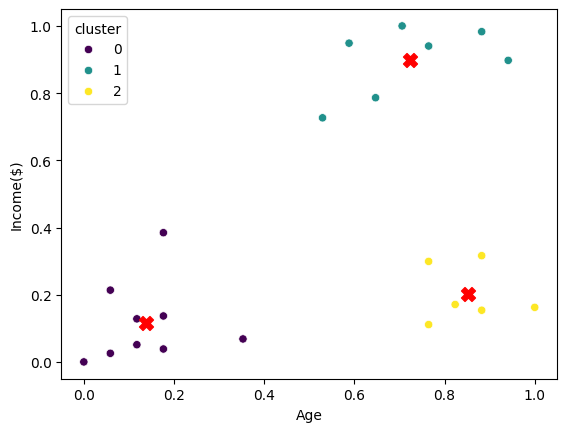

In [20]:
df_scaled["cluster"] = kmeans.labels_
sns.scatterplot(x="Age", y="Income($)", hue="cluster", data=df_scaled, palette="viridis")
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color="red", marker="X", s=100)
plt.show()

In [21]:
sse = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=0)
    kmeans.fit(df_scaled[["Age", "Income($)"]])
    sse.append(kmeans.inertia_)

In [22]:
sse

[5.434011511988178,
 2.091136388699078,
 0.4750783498553096,
 0.3687734076440591,
 0.2957980749806379,
 0.24004511510980914,
 0.20411419102196318,
 0.16352624304632407,
 0.10188787724979426]

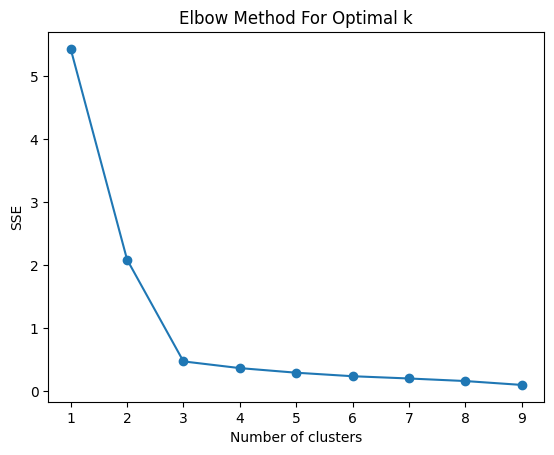

In [23]:
plt.plot(range(1, 10), sse, marker='o')
plt.xlabel('Number of clusters')    
plt.ylabel('SSE')
plt.title('Elbow Method For Optimal k')
plt.show()